# Static second-order conditioning with the sequential particle filter

This notebook is the original-experiment particle-filter workflow under `static/`. It reruns the second-order conditioning study, saves the main notebook figures, and exports representative latent-feature summaries to `outputs/images/` and `outputs/latent_data/`.


## Setup

Define the repeated-run particle-filter settings and the output locations used for the saved figures and latent summaries.


In [1]:
import csv
import json
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
repo_root = None
for candidate in (cwd, *cwd.parents):
    if (candidate / "static" / "models.py").exists():
        repo_root = candidate
        break
if repo_root is None:
    raise RuntimeError("Could not locate repository root containing static/models.py")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
notebook_dir = repo_root / "static" / "second-order_conditioning_experiment"
if str(notebook_dir) not in sys.path:
    sys.path.insert(0, str(notebook_dir))

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment

from sequential_particle_filter import DEFAULT_COND_LABELS, run_sequential_particle_filter

plt.style.use("ggplot")
np.set_printoptions(precision=3, suppress=True)

OUTPUT_DATA_DIR = Path("outputs") / "latent_data"
OUTPUT_IMAGE_DIR = Path("outputs") / "images"
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

SEED = 45
N_RUNS = 10
RUN_SEEDS = [SEED + idx for idx in range(N_RUNS)]

settings = dict(
    ax_max=60,
    seed=SEED,
    n_particles=64,
    K=20,
    alpha=0.1,
    rho=0.1,
    sigma_w=2.0,
    sigma_b=1.0,
    mu_b=(-6.0, -6.0, -6.0, -6.0),
    init_n_iter=2500,
    init_burn=1000,
    latent_update_candidates=256,
    query_candidates=256,
    ess_threshold_fraction=0.5,
    rejuvenation_sweeps_per_resample=1,
    model_variant="bernoulli",
)

{"n_runs": N_RUNS, "run_seeds": RUN_SEEDS, "settings": settings}


{'n_runs': 10,
 'run_seeds': [45, 46, 47, 48, 49, 50, 51, 52, 53, 54],
 'settings': {'ax_max': 60,
  'seed': 45,
  'n_particles': 64,
  'K': 20,
  'alpha': 0.1,
  'rho': 0.1,
  'sigma_w': 2.0,
  'sigma_b': 1.0,
  'mu_b': (-6.0, -6.0, -6.0, -6.0),
  'init_n_iter': 2500,
  'init_burn': 1000,
  'latent_update_candidates': 256,
  'query_candidates': 256,
  'ess_threshold_fraction': 0.5,
  'rejuvenation_sweeps_per_resample': 1,
  'model_variant': 'bernoulli'}}

## Repeated runs and aggregate curves

The repeated runs below build the posterior predictive curves, ESS diagnostics, and occupied-feature summaries that feed both the saved figure set and the representative structure summaries.


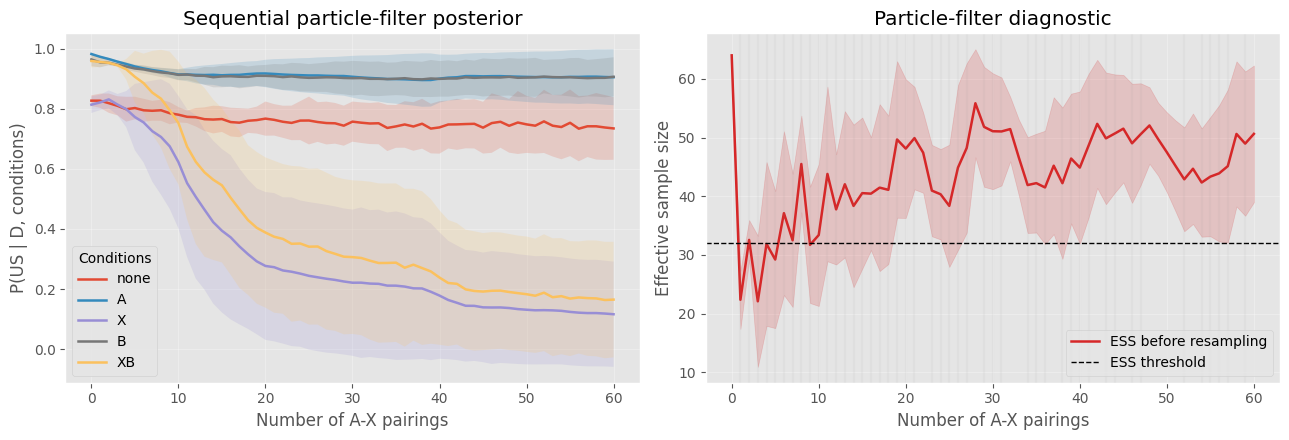

[{'ax_pairs': 0,
  'ESS_mean': 64.0,
  'ESS_std': 0.0,
  'mean_occupied_features': 2.4984375,
  'occupied_std': 0.11448978188576481,
  'none_mean': 0.8266676777833861,
  'none_std': 0.017838222418287,
  'A_mean': 0.9819341883664047,
  'A_std': 0.0011087601116569214,
  'X_mean': 0.8133916733525586,
  'X_std': 0.02762261362921129,
  'B_mean': 0.9637021953060858,
  'B_std': 0.022172786515574965,
  'XB_mean': 0.9587114270634501,
  'XB_std': 0.021365305518735927},
 {'ax_pairs': 1,
  'ESS_mean': 64.0,
  'ESS_std': 0.0,
  'mean_occupied_features': 2.4734375,
  'occupied_std': 0.13658252141562624,
  'none_mean': 0.8266168015222781,
  'none_std': 0.023495841074064855,
  'A_mean': 0.9727310558990396,
  'A_std': 0.0030479908541115783,
  'X_mean': 0.8208464984825443,
  'X_std': 0.025607045211723092,
  'B_mean': 0.9542330395890932,
  'B_std': 0.016630231457984812,
  'XB_mean': 0.955466904398348,
  'XB_std': 0.016695688428685546},
 {'ax_pairs': 2,
  'ESS_mean': 43.25519052482918,
  'ESS_std': 13.637

In [2]:
all_results = []
for run_seed in RUN_SEEDS:
    run_settings = dict(settings)
    run_settings["seed"] = run_seed
    run_settings["snapshot_ax_values"] = list(range(settings["ax_max"] + 1))
    all_results.append(run_sequential_particle_filter(**run_settings))

ax_values = np.asarray(all_results[0]["ax_values"], dtype=int)
conds_list = all_results[0]["conds_list"]
cond_labels = all_results[0]["cond_labels"]

posterior_runs = {
    str(conds): np.asarray([result["posterior_probs"][str(conds)] for result in all_results], dtype=float)
    for conds in conds_list
}
ess_before_runs = np.asarray([result["ess_before_resample_history"] for result in all_results], dtype=float)
ess_after_runs = np.asarray([result["ess_history"] for result in all_results], dtype=float)
occupied_runs = np.asarray([result["occupied_history"] for result in all_results], dtype=float)

posterior_mean = {key: values.mean(axis=0) for key, values in posterior_runs.items()}
posterior_std = {key: values.std(axis=0) for key, values in posterior_runs.items()}
ess_before_mean = ess_before_runs.mean(axis=0)
ess_before_std = ess_before_runs.std(axis=0)
ess_after_mean = ess_after_runs.mean(axis=0)
ess_after_std = ess_after_runs.std(axis=0)
occupied_mean = occupied_runs.mean(axis=0)
occupied_std = occupied_runs.std(axis=0)

summary_rows = []
for idx, ax_pairs in enumerate(ax_values):
    row = {
        "ax_pairs": int(ax_pairs),
        "ESS_mean": float(ess_after_mean[idx]),
        "ESS_std": float(ess_after_std[idx]),
        "mean_occupied_features": float(occupied_mean[idx]),
        "occupied_std": float(occupied_std[idx]),
    }
    for conds in conds_list:
        key = str(conds)
        row[f"{cond_labels[key]}_mean"] = float(posterior_mean[key][idx])
        row[f"{cond_labels[key]}_std"] = float(posterior_std[key][idx])
    summary_rows.append(row)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for conds in conds_list:
    key = str(conds)
    label = cond_labels[key]
    mean_values = posterior_mean[key]
    std_values = posterior_std[key]
    axes[0].plot(ax_values, mean_values, linewidth=1.8, label=label)
    axes[0].fill_between(ax_values, mean_values - std_values, mean_values + std_values, alpha=0.18)

axes[0].set_xlabel("Number of A-X pairings")
axes[0].set_ylabel("P(US | D, conditions)")
axes[0].set_title("Sequential particle-filter posterior")
axes[0].grid(True, alpha=0.3)
axes[0].legend(title="Conditions")

axes[1].plot(ax_values, ess_before_mean, color="tab:red", linewidth=1.8, label="ESS before resampling")
axes[1].fill_between(ax_values, ess_before_mean - ess_before_std, ess_before_mean + ess_before_std, color="tab:red", alpha=0.18)
#axes[1].plot(ax_values, ess_after_mean, color="tab:orange", linewidth=1.3, label="ESS after resampling")
#axes[1].fill_between(ax_values, ess_after_mean - ess_after_std, ess_after_mean + ess_after_std, color="tab:orange", alpha=0.14)
axes[1].axhline(settings["n_particles"] * settings["ess_threshold_fraction"], color="black", linestyle="--", linewidth=1.0, label="ESS threshold")

for step in sorted({step for result in all_results for step in result["resampled_at"]}):
    axes[1].axvline(step, color="tab:gray", alpha=0.06)

axes[1].set_xlabel("Number of A-X pairings")
axes[1].set_ylabel("Effective sample size")
axes[1].set_title("Particle-filter diagnostic")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
posterior_fig_path = OUTPUT_IMAGE_DIR / "second_order_pf_posterior_and_ess.png"
fig.savefig(posterior_fig_path, dpi=200, bbox_inches="tight")
plt.show()

summary_rows[:5]


## Representative phases and latent structure

The next section picks one early second-order point and one later latent-inhibition point, then pools particles at those points to summarize active latent counts, aligned effective weights, and observed-dimension biases.


## Saved phase summaries

Use the pooled particles at the representative phases to write out aligned weights, observed biases, and the phase-selection details.


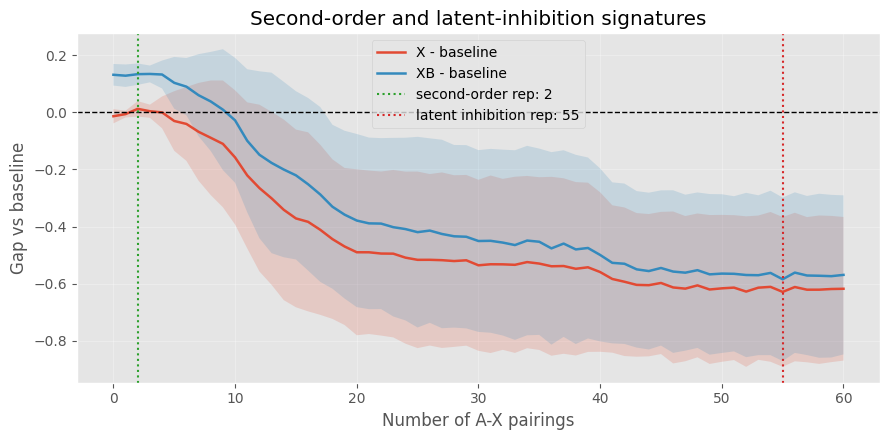

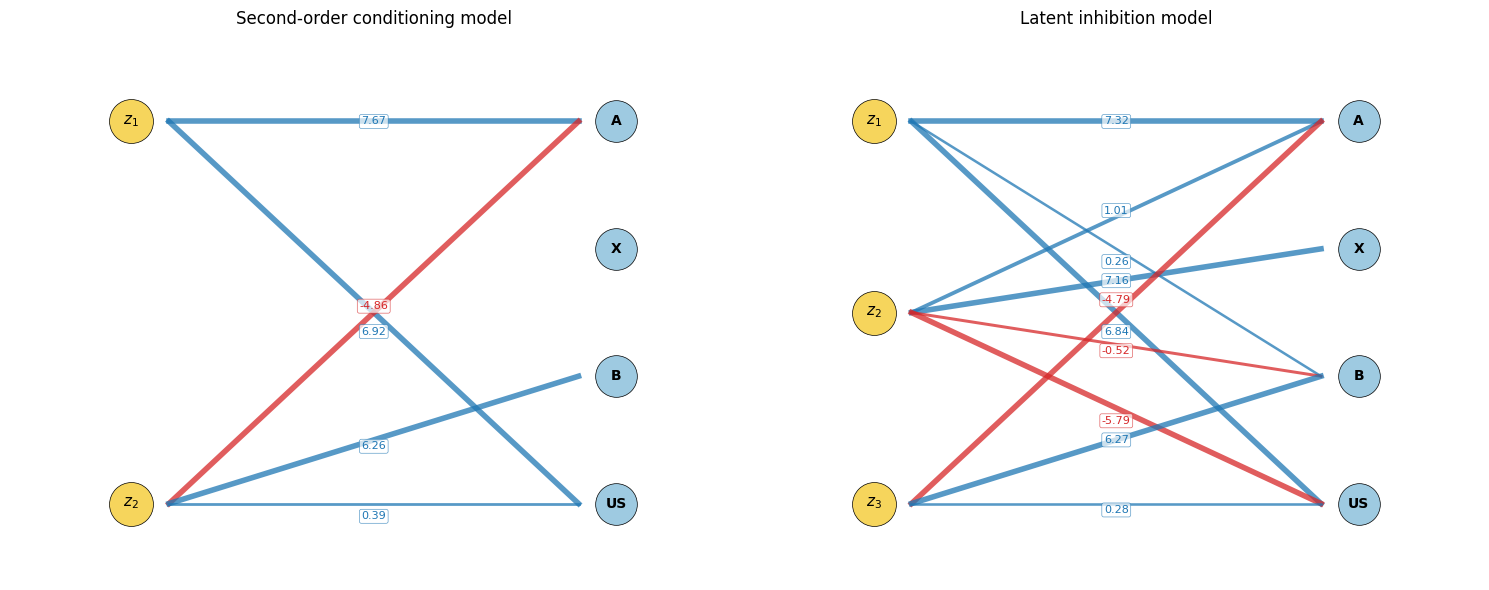

{'curves_csv': 'outputs/latent_data/second_order_pf_curves.csv', 'summary_json': 'outputs/latent_data/second_order_pf_summary.json', 'findings_txt': 'outputs/latent_data/second_order_pf_findings.txt', 'posterior_and_ess': 'outputs/images/second_order_pf_posterior_and_ess.png', 'phase_gaps': 'outputs/images/second_order_pf_phase_gaps.png', 'structure': 'outputs/images/second_order_pf_structure.png'}


In [8]:
none_runs = posterior_runs[str([0, 0, 0])]
x_runs = posterior_runs[str([0, 1, 0])]
xb_runs = posterior_runs[str([0, 1, 1])]

x_gap_runs = x_runs - none_runs
xb_gap_runs = xb_runs - none_runs
inhibition_score_runs = (none_runs - x_runs) + (none_runs - xb_runs)

x_gap_mean = x_gap_runs.mean(axis=0)
x_gap_std = x_gap_runs.std(axis=0)
xb_gap_mean = xb_gap_runs.mean(axis=0)
xb_gap_std = xb_gap_runs.std(axis=0)
inhibition_score_mean = inhibition_score_runs.mean(axis=0)

early_mask = (ax_values >= 1) & (ax_values <= 10)
late_mask = ax_values >= 24

second_order_ax = int(ax_values[early_mask][np.argmax(x_gap_mean[early_mask])]) if np.any(early_mask) else int(ax_values[np.argmax(x_gap_mean)])
latent_inhibition_ax = int(ax_values[late_mask][np.argmax(inhibition_score_mean[late_mask])]) if np.any(late_mask) else int(ax_values[np.argmax(inhibition_score_mean)])

phase_selection = {
    "second_order_ax": second_order_ax,
    "latent_inhibition_ax": latent_inhibition_ax,
    "second_order_x_gap_mean": float(x_gap_mean[ax_values == second_order_ax][0]),
    "second_order_x_gap_std": float(x_gap_std[ax_values == second_order_ax][0]),
    "second_order_xb_gap_mean": float(xb_gap_mean[ax_values == second_order_ax][0]),
    "second_order_xb_gap_std": float(xb_gap_std[ax_values == second_order_ax][0]),
    "latent_inhibition_x_gap_mean": float(x_gap_mean[ax_values == latent_inhibition_ax][0]),
    "latent_inhibition_x_gap_std": float(x_gap_std[ax_values == latent_inhibition_ax][0]),
    "latent_inhibition_xb_gap_mean": float(xb_gap_mean[ax_values == latent_inhibition_ax][0]),
    "latent_inhibition_xb_gap_std": float(xb_gap_std[ax_values == latent_inhibition_ax][0]),
}

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ax_values, x_gap_mean, linewidth=1.8, label="X - baseline")
ax.fill_between(ax_values, x_gap_mean - x_gap_std, x_gap_mean + x_gap_std, alpha=0.18)
ax.plot(ax_values, xb_gap_mean, linewidth=1.8, label="XB - baseline")
ax.fill_between(ax_values, xb_gap_mean - xb_gap_std, xb_gap_mean + xb_gap_std, alpha=0.18)
ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
ax.axvline(second_order_ax, color="tab:green", linestyle=":", linewidth=1.5, label=f"second-order rep: {second_order_ax}")
ax.axvline(latent_inhibition_ax, color="tab:red", linestyle=":", linewidth=1.5, label=f"latent inhibition rep: {latent_inhibition_ax}")
ax.set_xlabel("Number of A-X pairings")
ax.set_ylabel("Gap vs baseline")
ax.set_title("Second-order and latent-inhibition signatures")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
phase_gap_fig_path = OUTPUT_IMAGE_DIR / "second_order_pf_phase_gaps.png"
fig.savefig(phase_gap_fig_path, dpi=200, bbox_inches="tight")
plt.show()

ACTIVE_COUNT_THRESHOLD = 5
EDGE_WEIGHT_THRESHOLD = 0.5
OBSERVED_NODE_LABELS = ["A", "X", "B", "US"]


def pooled_snapshot(ax_value):
    pooled_particles = []
    pooled_weights = []
    run_weight = 1.0 / len(all_results)
    for result in all_results:
        snapshot = result["snapshots"][ax_value]
        weights = np.asarray(snapshot["weights"], dtype=float)
        if weights.sum() <= 0:
            weights = np.full(len(weights), 1.0 / len(weights), dtype=float)
        else:
            weights = weights / weights.sum()
        pooled_particles.extend(snapshot["particles"])
        pooled_weights.extend(run_weight * weights)
    return {"particles": pooled_particles, "weights": np.asarray(pooled_weights, dtype=float)}


def summarize_snapshot(snapshot, phase_key, ax_value):
    particles = snapshot["particles"]
    weights = np.asarray(snapshot["weights"], dtype=float)
    if weights.sum() <= 0:
        weights = np.full(len(weights), 1.0 / len(weights), dtype=float)
    else:
        weights = weights / weights.sum()

    active_counts = np.array([np.sum(particle.Z.sum(axis=0) > ACTIVE_COUNT_THRESHOLD) for particle in particles], dtype=int)
    eligible = np.flatnonzero(active_counts > 0)
    if eligible.size == 0:
        raise ValueError(f"No active latent features found at A-X={ax_value}.")

    active_count_values = active_counts[eligible]
    unique_counts, sample_counts = np.unique(active_count_values, return_counts=True)
    target_count = int(unique_counts[np.argmax(sample_counts)])
    candidates = eligible[active_counts[eligible] == target_count]
    sample_count = int(candidates.size)
    reference_idx = int(candidates[np.argmax(weights[candidates])])

    reference_particle = particles[reference_idx]
    ref_occupancy = reference_particle.Z.sum(axis=0)
    ref_active_idx = np.flatnonzero(ref_occupancy > ACTIVE_COUNT_THRESHOLD)
    ref_vectors = reference_particle.effective_weights()[ref_active_idx]

    selected_weights = weights[candidates]
    if selected_weights.sum() <= 0:
        selected_weights = np.full(candidates.size, 1.0 / candidates.size, dtype=float)
    else:
        selected_weights = selected_weights / selected_weights.sum()

    slot_vector_sum = np.zeros_like(ref_vectors, dtype=float)
    slot_occupancy_sum = np.zeros(ref_active_idx.size, dtype=float)
    bias_sum = np.zeros(reference_particle.S, dtype=float)

    for particle_idx, particle_weight in zip(candidates, selected_weights):
        particle = particles[particle_idx]
        if particle_weight <= 0:
            continue

        occupancy = particle.Z.sum(axis=0)
        active_idx = np.flatnonzero(occupancy > ACTIVE_COUNT_THRESHOLD)
        if active_idx.size != target_count:
            continue

        vectors = particle.effective_weights()[active_idx]
        cost = np.linalg.norm(ref_vectors[:, None, :] - vectors[None, :, :], axis=2)
        row_ind, col_ind = linear_sum_assignment(cost)
        bias_sum += particle_weight * particle.b

        for row, col in zip(row_ind, col_ind):
            slot_vector_sum[row] += particle_weight * vectors[col]
            slot_occupancy_sum[row] += particle_weight * occupancy[active_idx[col]]

    order = np.argsort(-slot_occupancy_sum)
    gap_idx = int(np.where(ax_values == ax_value)[0][0])
    titles = {
        "second_order": "Second-order conditioning model",
        "latent_inhibition": "Latent inhibition model",
    }
    return {
        "phase_key": phase_key,
        "title": titles[phase_key],
        "ax_value": ax_value,
        "reference_idx": reference_idx,
        "latent_count": target_count,
        "sample_count": sample_count,
        "avg_vectors": slot_vector_sum[order],
        "avg_occupancy": slot_occupancy_sum[order],
        "avg_bias": bias_sum,
        "x_gap_mean": float(x_gap_mean[gap_idx]),
        "x_gap_std": float(x_gap_std[gap_idx]),
        "xb_gap_mean": float(xb_gap_mean[gap_idx]),
        "xb_gap_std": float(xb_gap_std[gap_idx]),
    }


def plot_structure_schematic(ax, structure):
    vectors = np.asarray(structure["avg_vectors"], dtype=float)
    if vectors.shape[0] == 0:
        ax.text(0.5, 0.5, "No active latent structure", ha="center", va="center")
        ax.axis("off")
        return

    height = max(vectors.shape[0] - 1, len(OBSERVED_NODE_LABELS) - 1)
    latent_y = np.linspace(height, 0, vectors.shape[0])
    observed_y = np.linspace(height, 0, len(OBSERVED_NODE_LABELS))
    x_latent = 0.0
    x_observed = 1.8
    ax.set_xlim(-0.45, 2.25)
    ax.set_ylim(-0.6, height + 0.7)
    ax.axis("off")

    for idx, y_pos in enumerate(latent_y, start=1):
        ax.scatter(x_latent, y_pos, s=1000, color="#f6d55c", edgecolor="black", zorder=3)
        ax.text(x_latent, y_pos, rf"$z_{{{idx}}}$", ha="center", va="center", fontsize=11)

    for label, y_pos in zip(OBSERVED_NODE_LABELS, observed_y):
        ax.scatter(x_observed, y_pos, s=900, color="#9ecae1", edgecolor="black", zorder=3)
        ax.text(x_observed, y_pos, label, ha="center", va="center", fontsize=10, fontweight="bold")

    for latent_idx, y_latent in enumerate(latent_y):
        for obs_idx, y_obs in enumerate(observed_y):
            weight = vectors[latent_idx, obs_idx]
            if abs(weight) < EDGE_WEIGHT_THRESHOLD:
                continue
            color = "tab:blue" if weight > 0 else "tab:red"
            linewidth = 1.5 + 2.5 * min(abs(weight), 2.0) / 2.0
            ax.plot([x_latent + 0.14, x_observed - 0.14], [y_latent, y_obs], color=color, linewidth=linewidth, alpha=0.75)
            label_y = 0.5 * (y_latent + y_obs) + 0.05 * (latent_idx - obs_idx)
            ax.text(0.5 * (x_latent + x_observed), label_y, f"{weight:.2f}", color=color, fontsize=8, ha="center", va="center", bbox=dict(boxstyle="round,pad=0.18", fc="white", ec=color, alpha=0.7))
    ax.set_title(structure["title"], fontsize=12)


phase_structures = {
    "second_order": summarize_snapshot(pooled_snapshot(phase_selection["second_order_ax"]), phase_key="second_order", ax_value=phase_selection["second_order_ax"]),
    "latent_inhibition": summarize_snapshot(pooled_snapshot(phase_selection["latent_inhibition_ax"]), phase_key="latent_inhibition", ax_value=phase_selection["latent_inhibition_ax"]),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
plot_structure_schematic(axes[0], phase_structures["second_order"])
plot_structure_schematic(axes[1], phase_structures["latent_inhibition"])
fig.tight_layout()
structure_fig_path = OUTPUT_IMAGE_DIR / "second_order_pf_structure.png"
fig.savefig(structure_fig_path, dpi=200, bbox_inches="tight")
plt.show()

curves_csv_path = OUTPUT_DATA_DIR / "second_order_pf_curves.csv"
summary_json_path = OUTPUT_DATA_DIR / "second_order_pf_summary.json"
findings_txt_path = OUTPUT_DATA_DIR / "second_order_pf_findings.txt"

with curves_csv_path.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(summary_rows[0].keys()))
    writer.writeheader()
    writer.writerows(summary_rows)

serializable_structures = {
    key: {
        **value,
        "avg_vectors": np.asarray(value["avg_vectors"], dtype=float).tolist(),
        "avg_occupancy": np.asarray(value["avg_occupancy"], dtype=float).tolist(),
        "avg_bias": np.asarray(value["avg_bias"], dtype=float).tolist(),
    }
    for key, value in phase_structures.items()
}

summary_payload = {
    "settings": settings,
    "run_seeds": RUN_SEEDS,
    "resampled_at": [result["resampled_at"] for result in all_results],
    "phase_selection": phase_selection,
    "phase_structures": serializable_structures,
    "summary_rows": summary_rows,
    "image_outputs": {
        "posterior_and_ess": str(posterior_fig_path),
        "phase_gaps": str(phase_gap_fig_path),
        "structure": str(structure_fig_path),
    },
}
with summary_json_path.open("w") as f:
    json.dump(summary_payload, f, indent=2)

with findings_txt_path.open("w") as f:
    f.write("Static sequential particle-filter second-order conditioning\n")
    f.write("Settings:\n")
    for key, value in settings.items():
        f.write(f"  {key}: {value}\n")
    f.write(f"  run_seeds: {RUN_SEEDS}\n")
    f.write("\nRepresentative phase picks:\n")
    for key, value in phase_selection.items():
        f.write(f"  {key}: {value}\n")
    for key, structure in serializable_structures.items():
        f.write(f"\n{structure['title']}\n")
        f.write(f"  ax_value: {structure['ax_value']}\n")
        f.write(f"  active_features: {structure['latent_count']}\n")
        f.write(f"  pooled_particles: {structure['sample_count']}\n")
        f.write(f"  avg_bias: {np.array2string(np.array(structure['avg_bias']), precision=3)}\n")
        f.write(f"  aligned_effective_weights:\n{np.array2string(np.array(structure['avg_vectors']), precision=3)}\n")
        f.write(f"  aligned_occupancy:\n{np.array2string(np.array(structure['avg_occupancy']), precision=3)}\n")
    f.write("\nSaved figures:\n")
    f.write(f"  posterior_and_ess: {posterior_fig_path}\n")
    f.write(f"  phase_gaps: {phase_gap_fig_path}\n")
    f.write(f"  structure: {structure_fig_path}\n")

print({
    "curves_csv": str(curves_csv_path),
    "summary_json": str(summary_json_path),
    "findings_txt": str(findings_txt_path),
    "posterior_and_ess": str(posterior_fig_path),
    "phase_gaps": str(phase_gap_fig_path),
    "structure": str(structure_fig_path),
})
